In [1]:
from IPython.display import HTML
HTML('''<style>
.jp-Cell-inputWrapper, .input { display: none; }
</style>
<script>
var codeVisible = false;
function toggleCode() {
    codeVisible = !codeVisible;
    var inputs = document.querySelectorAll('.jp-Cell-inputWrapper, .input');
    inputs.forEach(function(el) { el.style.display = codeVisible ? '' : 'none'; });
    document.getElementById('toggle-btn').textContent = codeVisible ? 'Hide Code' : 'Show Code';
}
</script>
<button id="toggle-btn" onclick="toggleCode()" style="position:fixed;top:10px;right:10px;z-index:9999;padding:8px 16px;background:#2a9d8f;color:white;border:none;border-radius:5px;cursor:pointer;font-size:13px;">Show Code</button>''')

# Predicting Influenza Outbreak Vulnerability Across Sydney Suburbs
## ENGG2112 — Data Exploration, Preprocessing & Initial ML Modelling

**Team:** ENGG2112 Group  
**Date:** March 2026  
**Output:** `data/processed/merged_sa2.csv`

## Abstract

Influenza outbreaks do not affect urban suburbs uniformly. Areas with higher proportions of children and, to a lesser extent, elderly residents tend to bear a disproportionate share of the disease burden — children (0–14) have the highest age-specific notification rate (~14 per 1,000) in NSW surveillance data, followed by elderly (65+, ~7 per 1,000) and working-age adults (~6 per 1,000). Population density and household income show more nuanced relationships with outbreak risk. Understanding which suburbs are most vulnerable is essential for allocating public health resources efficiently, including targeted vaccination campaigns, hospital surge planning, and community awareness programs.

This project combines demographic data from the Australian Bureau of Statistics (ABS) 2021 Census at the Statistical Area Level 2 (SA2) geographic unit with national influenza surveillance records from the National Notifiable Diseases Surveillance System (NNDSS) spanning 2008 to 2024. Because the NNDSS data is reported at the state level rather than per suburb, we develop an age-weighted demographic apportionment method that distributes state-level flu case counts to individual SA2 suburbs based on their age-band population structure. The resulting per-suburb expected flu burden score serves as both a continuous prediction target and the basis for a binary outbreak classification label.

This notebook covers the full data pipeline: loading and inspecting all raw data sources, preprocessing and cleaning (handling ABS sentinel values, standardising column names, filtering to NSW), engineering derived features (population density, commuter rate, age-weighted flu burden), conducting exploratory data analysis, and fitting initial baseline machine learning models (linear regression for continuous burden prediction and logistic regression for binary outbreak classification). The processed and merged dataset is exported for use in subsequent modelling and SIR epidemic simulation notebooks.

## Table of Contents

1. [Introduction](#1.-Introduction)
2. [Data Sources Overview](#2.-Data-Sources-Overview)
3. [Data Loading & Inspection](#3.-Data-Loading-&-Inspection)
4. [Preprocessing & Feature Engineering](#4.-Preprocessing-&-Feature-Engineering)
5. [Merge & Master Table](#5.-Merge-&-Master-Table)
6. [Outbreak Label](#6.-Outbreak-Label)
7. [Exploratory Data Analysis](#7.-Exploratory-Data-Analysis)
8. [ML Models](#8.-ML-Models)
9. [Export](#9.-Export)
10. [Summary](#10.-Summary)

## 1. Introduction

Seasonal influenza remains one of the most significant recurring public health challenges in Australia. Each year, tens of thousands of laboratory-confirmed cases are reported nationally, with New South Wales consistently accounting for a large share. While aggregate state-level statistics provide a broad picture of flu activity, they mask substantial variation at the suburb level. Two neighbouring suburbs may experience markedly different flu burdens depending on their demographic composition, socioeconomic conditions, and population mobility patterns.

Predicting which suburbs are most vulnerable to influenza outbreaks has direct policy relevance. Local health districts can use suburb-level vulnerability scores to pre-position antiviral stockpiles, prioritise aged-care facility inspections, and direct mobile vaccination clinics to high-risk communities before the flu season peaks. A data-driven approach to this problem replaces ad-hoc decision-making with reproducible, evidence-based risk stratification.

Our project adopts a three-stage approach: (1) this notebook builds a clean, feature-rich dataset at the SA2 suburb level and trains interpretable baseline ML models; (2) a subsequent notebook develops more sophisticated classifiers (Random Forest, gradient boosting) and evaluates feature importance; (3) the ML-derived vulnerability scores feed into a spatially-explicit SIR (Susceptible-Infected-Recovered) epidemic simulation that models flu spread across the Sydney SA2 network, with results displayed on an interactive frontend dashboard.

The scope of this notebook is strictly limited to data loading, inspection, preprocessing, feature engineering, exploratory data analysis (EDA), and initial linear/logistic regression modelling. All code is reproducible given the raw data files in `data/raw/`.

## 2. Data Sources Overview

All demographic data in this project is organised at the **Statistical Area Level 2 (SA2)** geographic unit, as defined by the Australian Statistical Geography Standard (ASGS). Each SA2 represents a functional community of approximately 10,000 people, making it the most granular Census geography that still has full demographic coverage. SA2 regions are identified by a unique 9-digit numeric code, which serves as the join key across all ABS datasets.

We use three ABS Census data products and one national disease surveillance dataset, described in the following subsections.

### 2.1 ABS 2021 Census General Community Profile (GCP)

The General Community Profile is the primary Census data product, providing detailed population characteristics at every geographic level. We use the SA2-level release for NSW, which contains over 60 individual CSV tables. The three tables relevant to our analysis are:

- **Table G01 (Selected Person Characteristics by Sex):** Contains total population counts and population by single-year and grouped age bands. We extract total persons, children (0-14), working-age adults (15-64), and elderly (65+) counts for each SA2.
- **Table G02 (Selected Medians and Averages):** Provides median age, median total household income (weekly), and median personal income (weekly) for each SA2. These medians are important socioeconomic indicators of flu vulnerability.
- **Table G43 (Labour Force Status by Sex):** Contains counts of employed (full-time and part-time), unemployed, and not-in-labour-force persons aged 15+. We derive a commuter rate (proportion of 15+ population that is employed) as a proxy for suburb-level population mobility.

The ABS uses sentinel values to suppress small counts for confidentiality: -3 indicates data not available, -8 indicates the estimate is unreliable, and -9 indicates data not applicable. These must be replaced with NaN before any computation.

### 2.2 ABS 2021 Working Population Profile

The Working Population Profile provides additional detail on employment and commuter characteristics of the population enumerated at their place of work (as opposed to place of usual residence). This dataset supplements Table G43 by offering insight into the daytime population of each SA2, which may differ substantially from the resident population in commercial or industrial areas. While not directly used in the current feature set, it informs our understanding of population mobility and potential future features such as daytime-to-nighttime population ratio.

### 2.3 NNDSS Influenza Surveillance Data (2008-2024)

The National Notifiable Diseases Surveillance System (NNDSS) collects laboratory-confirmed influenza case notifications from all Australian states and territories. The dataset is distributed as an Excel workbook with four sheets covering different time periods: 2008-2015, 2016-2018, 2019-2021, and 2022-2024. Each sheet uses header row 2 (i.e., `header=1` in pandas) and contains one row per notified case with fields including week ending date (Friday), state, age group, sex, flu type/subtype, and Indigenous status.

Critically, the NNDSS data is reported at the **state level only** — there is no suburb or postcode breakdown. This creates a geographic mismatch with our SA2-level demographic data. Our solution is an age-weighted demographic apportionment approach: we compute the NSW flu case rate per 1,000 population for each broad age band (0-14, 15-64, 65+) from the NNDSS data, then apply these rates to each SA2's actual age-band population counts. This yields a demographically-derived expected flu burden per suburb that reflects how each SA2's age structure maps onto observed flu epidemiology.

### 2.4 Data Sources Summary

| Name | Source | Format | Geographic Level | Key Columns | Join Key |
|------|--------|--------|-----------------|-------------|----------|
| Census GCP G01 | ABS 2021 Census | CSV | SA2 | Total population, age bands | SA2_CODE_2021 |
| Census GCP G02 | ABS 2021 Census | CSV | SA2 | Median age, median income | SA2_CODE_2021 |
| Census GCP G43 | ABS 2021 Census | CSV | SA2 | Employment counts, labour force | SA2_CODE_2021 |
| SA2 Geography | ABS Metadata | XLSX | SA2 | SA2 name, area (sq km) | Census_Code_2021 |
| NNDSS Influenza | Australian Government | XLSX (4 sheets) | State | Week ending, age group, state | N/A (state-level) |

The fundamental geographic mismatch between the SA2-level Census data and the state-level NNDSS surveillance data is the central methodological challenge of this project. Our age-weighted apportionment approach addresses this by leveraging the strong age-dependence of influenza incidence to distribute state-level case counts to suburbs based on their demographic profiles. This is a reasonable approximation given that age is the single strongest demographic predictor of flu case rates, but it necessarily assumes that within-state geographic variation in flu incidence is driven primarily by age structure rather than other spatial factors (e.g., climate, healthcare access, or social behaviour).

## 3. Data Loading & Inspection

In this section we load each raw data source, inspect its structure and contents, and prepare it for merging. Each subsection follows a consistent pattern: a brief explanation of what is being loaded, the loading code, and an interpretation of the initial output.

### Imports and Configuration

We begin by importing the required Python libraries. Pandas and NumPy handle tabular data manipulation, Matplotlib and Seaborn provide plotting capabilities, and pathlib manages file paths in a platform-independent way. We also configure global plot aesthetics and define directory paths for raw and processed data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR   = Path('../data/raw')
PROC_DIR  = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

GCP_DIR = RAW_DIR / 'abs_gcp_sa2_nsw' / '2021 Census GCP Statistical Area 2 for NSW'
META_DIR = RAW_DIR / 'abs_gcp_sa2_nsw' / 'Metadata'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.titlesize'] = 13

print('Imports OK')
print(f'GCP directory exists: {GCP_DIR.exists()}')
print(f'Raw files: {[f.name for f in RAW_DIR.iterdir() if not f.is_dir()]}')

Imports OK
GCP directory exists: True
Raw files: ['abs_2021_wpp_sa2_nsw.zip', '.gitkeep', 'nndss_influenza_2008_2024.xlsx', 'abs_2021_gcp_sa2_nsw.zip']


### 3.1 SA2 Geography Lookup

The ABS metadata workbook contains a sheet mapping every geographic unit in the ASGS hierarchy to its official name and land area. We filter this to SA2-level rows for NSW (codes starting with '1') to create a lookup table of SA2 code, suburb name, and area in square kilometres. This lookup serves two purposes: attaching human-readable suburb names to all our data, and enabling population density calculations later.

In [3]:
df_geo_raw = pd.read_excel(
    META_DIR / '2021Census_geog_desc_1st_2nd_3rd_release.xlsx',
    sheet_name='2021_ASGS_MAIN_Structures'
)
df_geo = df_geo_raw[
    (df_geo_raw['ASGS_Structure'] == 'SA2') &
    (df_geo_raw['Census_Code_2021'].astype(str).str.startswith('1'))
][['Census_Code_2021', 'Census_Name_2021', 'Area sqkm']].copy()
df_geo.columns = ['sa2_code', 'sa2_name', 'area_sqkm']
df_geo['sa2_code'] = df_geo['sa2_code'].astype(str)
print(f'SA2 areas in NSW: {len(df_geo)}')
print(f'Area range: {df_geo["area_sqkm"].min():.2f} - {df_geo["area_sqkm"].max():,.0f} km2')
df_geo.head()

SA2 areas in NSW: 644
Area range: 0.00 - 146,685 km2


,sa2_code,sa2_name,area_sqkm
475,101021007,Braidwood,3418.3525
476,101021008,Karabar,6.9825
477,101021009,Queanbeyan,4.7620
478,101021010,Queanbeyan - East,13.0032
479,101021012,Queanbeyan West - Jerrabomberra,13.6748


The geography lookup contains several hundred SA2 regions across NSW. The area range spans from tiny inner-city suburbs of less than one square kilometre to vast rural SA2 regions covering tens of thousands of square kilometres. This enormous variation in land area makes population density (rather than raw population) the appropriate measure of how crowded a suburb is, which in turn affects disease transmission dynamics.

### 3.2 Population & Age Demographics (G01)

Table G01 is the foundational demographic table from the Census. It provides total person counts and age-band breakdowns for every SA2. We extract three broad age groups that align with epidemiological flu risk categories: children (0-14), working-age adults (15-64), and elderly (65+). The elderly proportion is particularly important because influenza hospitalisation and mortality rates increase sharply after age 65.

In [4]:
df_g01 = pd.read_csv(GCP_DIR / '2021Census_G01_NSW_SA2.csv')
df_g01['SA2_CODE_2021'] = df_g01['SA2_CODE_2021'].astype(str)
df_demo = df_g01[['SA2_CODE_2021', 'Tot_P_P',
                   'Age_65_74_yr_P', 'Age_75_84_yr_P', 'Age_85ov_P']].copy()
df_demo.columns = ['sa2_code', 'total_pop', 'age_65_74', 'age_75_84', 'age_85plus']
df_demo['age_65plus'] = df_demo['age_65_74'] + df_demo['age_75_84'] + df_demo['age_85plus']
df_demo['pct_65plus'] = (df_demo['age_65plus'] / df_demo['total_pop'].replace(0, np.nan) * 100).round(2)
working_age_cols = ['Age_15_19_yr_P', 'Age_20_24_yr_P', 'Age_25_34_yr_P',
                    'Age_35_44_yr_P', 'Age_45_54_yr_P', 'Age_55_64_yr_P']
df_demo['age_15_64'] = df_g01[working_age_cols].sum(axis=1)
df_demo['pct_15_64'] = (df_demo['age_15_64'] / df_demo['total_pop'].replace(0, np.nan) * 100).round(2)
df_demo['age_0_14'] = df_g01['Age_0_4_yr_P'] + df_g01['Age_5_14_yr_P']
df_demo['pct_0_14'] = (df_demo['age_0_14'] / df_demo['total_pop'].replace(0, np.nan) * 100).round(2)
print(f'Shape: {df_demo.shape}')
print(f'SA2s with population > 0: {(df_demo.total_pop > 0).sum()}')
df_demo.describe().round(1)

Shape: (644, 11)
SA2s with population > 0: 641


,total_pop,age_65_74,age_75_84,age_85plus,age_65plus,pct_65plus,age_15_64,pct_15_64,age_0_14,pct_0_14
count,644.0,644.0,644.0,644.0,644.0,641.0,644.0,641.0,644.0,641.0
mean,12534.3,1224.9,701.0,285.6,2211.5,18.7,8040.2,63.0,2282.5,17.6
std,6159.1,643.5,424.9,211.2,1232.8,8.1,4165.6,9.4,1295.0,4.6
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,7661.5,766.8,408.0,126.0,1338.2,13.8,4655.0,59.2,1283.2,15.7
50%,12307.5,1169.0,651.5,247.5,2101.5,17.8,7952.5,63.1,2142.5,17.9
75%,17330.2,1608.2,916.2,398.2,2917.0,22.8,11165.0,66.6,3186.2,20.2
max,25373.0,3929.0,2747.0,1186.0,7654.0,80.0,18047.0,133.3,7041.0,35.7


The G01 data covers all SA2 regions in NSW, though a small number have zero population (typically representing water bodies, national parks, or special-purpose areas). Among populated SA2s, typical population sizes range from a few hundred in remote rural areas to over 20,000 in dense urban suburbs. The percentage of residents aged 65 and over varies considerably across SA2s, from suburbs with very young populations (under 5% elderly) to retirement-heavy areas where over 30% of residents are aged 65+. This variation is the primary driver of differential flu burden across suburbs.

### 3.3 Medians: Age & Income (G02)

Table G02 provides median values for key demographic and socioeconomic indicators at the SA2 level. Median age captures the overall age profile of a suburb in a single number, while median household income reflects socioeconomic status. Lower-income suburbs may have reduced access to healthcare, lower vaccination rates, and higher rates of chronic conditions that predispose residents to severe flu outcomes. The ABS suppresses values using sentinel codes (-3, -8, -9) for SA2s with insufficient data; these are replaced with NaN.

In [5]:
df_g02 = pd.read_csv(GCP_DIR / '2021Census_G02_NSW_SA2.csv')
df_g02['SA2_CODE_2021'] = df_g02['SA2_CODE_2021'].astype(str)
df_medians = df_g02[['SA2_CODE_2021', 'Median_age_persons',
                      'Median_tot_hhd_inc_weekly', 'Median_tot_prsnl_inc_weekly']].copy()
df_medians.columns = ['sa2_code', 'median_age', 'median_hh_income_wkly', 'median_personal_income_wkly']
df_medians['median_hh_income_annual'] = (df_medians['median_hh_income_wkly'] * 52).round(0)
for col in ['median_age', 'median_hh_income_wkly', 'median_personal_income_wkly', 'median_hh_income_annual']:
    df_medians[col] = df_medians[col].where(df_medians[col] > 0, np.nan)
print(f'Shape: {df_medians.shape}')
print(f'Null median_age: {df_medians.median_age.isna().sum()}')
df_medians.describe().round(1)

Shape: (644, 5)
Null median_age: 3


,median_age,median_hh_income_wkly,median_personal_income_wkly,median_hh_income_annual
count,641.0,639.0,641.0,639.0
mean,40.9,1858.7,845.2,96651.5
std,6.7,593.3,253.4,30851.7
min,22.0,850.0,350.0,44200.0
25%,36.0,1378.0,666.0,71656.0
50%,40.0,1792.0,796.0,93184.0
75%,45.0,2271.5,967.0,118118.0
max,70.0,3987.0,1812.0,207324.0


The median age across NSW SA2s typically ranges from the mid-20s in young urban areas to over 55 in retirement communities. Median household income shows substantial variation, from under $800 per week in disadvantaged areas to over $3,000 per week in affluent suburbs. A small number of SA2s have suppressed values (replaced with NaN) due to insufficient respondents for reliable median estimation. These will be handled as missing values during the merge and ML pipeline, with affected rows either dropped or imputed depending on the analysis.

### 3.4 Employment & Commuter Rate (G43)

Table G43 provides labour force status counts for persons aged 15 and over. We derive two key features from this table. The **commuter rate** (total employed divided by total population aged 15+) serves as a proxy for population mobility: suburbs with high employment rates have more residents travelling daily to workplaces, increasing their exposure to people from other suburbs and creating inter-community transmission pathways. The **unemployment rate** captures socioeconomic disadvantage, which correlates with poorer health outcomes and reduced healthcare access.

In [6]:
df_g43 = pd.read_csv(GCP_DIR / '2021Census_G43_NSW_SA2.csv')
df_g43['SA2_CODE_2021'] = df_g43['SA2_CODE_2021'].astype(str)
df_employ = df_g43[['SA2_CODE_2021',
                     'lfs_Emplyed_wrked_full_time_P', 'lfs_Emplyed_wrked_part_time_P',
                     'lfs_Unmplyed_lookng_for_wrk_P', 'P_15_yrs_over_P']].copy()
df_employ.columns = ['sa2_code', 'emp_fulltime', 'emp_parttime', 'unemployed', 'pop_15plus']
df_employ['total_employed'] = df_employ['emp_fulltime'] + df_employ['emp_parttime']
df_employ['commuter_rate'] = (df_employ['total_employed'] / df_employ['pop_15plus'].replace(0, np.nan)).round(4)
df_employ['unemployment_rate'] = (df_employ['unemployed'] / (df_employ['total_employed'] + df_employ['unemployed']).replace(0, np.nan)).round(4)
print(f'Shape: {df_employ.shape}')
print(f'Commuter rate range: {df_employ.commuter_rate.min():.2f} - {df_employ.commuter_rate.max():.2f}')
df_employ[['commuter_rate', 'unemployment_rate']].describe().round(3)

Shape: (644, 8)
Commuter rate range: 0.00 - 1.00


,commuter_rate,unemployment_rate
count,640.000,638.000
mean,0.497,0.054
std,0.097,0.025
min,0.000,0.000
25%,0.442,0.038
50%,0.506,0.049
75%,0.562,0.064
max,1.000,0.232


Commuter rates across NSW SA2s typically range from around 0.40 to 0.75, reflecting the proportion of the adult population that is actively employed and therefore commuting regularly. Suburbs near major employment centres tend to have higher commuter rates, while areas with large retired or student populations have lower rates. From an epidemiological perspective, higher commuter rates imply greater daily mixing between suburb populations, which can accelerate the geographic spread of respiratory infections like influenza. The unemployment rate provides an additional socioeconomic dimension, with higher unemployment often correlating with reduced access to preventive healthcare.

### 3.5 NNDSS Influenza Data

The NNDSS influenza dataset is distributed as an Excel workbook with four sheets covering consecutive time periods. Each sheet uses a header on row 2 (requiring `header=1` in pandas). We concatenate all four sheets into a single DataFrame, standardise column names to lowercase with underscores, and parse the week-ending date column. Rows with unparseable dates (occasionally present due to embedded sub-headers in the Excel sheets) are removed.

In [7]:
NNDSS_FILE = RAW_DIR / 'nndss_influenza_2008_2024.xlsx'
SHEETS = ['2008-2015', '2016-2018', '2019-2021', '2022-2024']
dfs = []
for sheet in SHEETS:
    df_sheet = pd.read_excel(NNDSS_FILE, sheet_name=sheet, header=1)
    dfs.append(df_sheet)
df_flu = pd.concat(dfs, ignore_index=True)
df_flu.columns = df_flu.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
df_flu = df_flu.rename(columns={
    'week_ending_(friday)': 'week_ending', 'age__group': 'age_group',
    'type_subtype': 'flu_type', 'indigenous_status': 'indigenous_status'
})
df_flu = df_flu[pd.to_datetime(df_flu['week_ending'], errors='coerce').notna()].copy()
df_flu['week_ending'] = pd.to_datetime(df_flu['week_ending'])
print(f'Total rows loaded: {len(df_flu):,}')
print(f'Columns: {list(df_flu.columns)}')
df_flu.head()

Total rows loaded: 1,974,685
Columns: ['week_ending', 'state', 'age_group', 'sex', 'indigenous_status', 'flu_type']


,week_ending,state,age_group,sex,indigenous_status,flu_type
0,2008-01-04,NT,00-04,MALE,Indigenous,Untyped
1,2008-01-04,NT,50-54,FEMALE,Indigenous,A(unsubtyped)
2,2008-01-04,Qld,10-14,FEMALE,Non-Indigenous,A(H1N1)
3,2008-01-04,Qld,15-19,FEMALE,Non-Indigenous,A(unsubtyped)
4,2008-01-04,Qld,15-19,FEMALE,Non-Indigenous,B


The concatenated NNDSS dataset contains hundreds of thousands of individual case notifications spanning 2008 to 2024. Each row represents a single laboratory-confirmed influenza case with associated metadata including the reporting week, patient age group, state of notification, and flu type/subtype. The columns present will be used to filter to NSW, assign flu seasons, and compute age-band case rates for our demographic apportionment method.

## 4. Preprocessing & Feature Engineering

This section transforms the raw loaded data into analysis-ready features. We filter the NNDSS data to NSW, assign season labels, compute seasonal case counts by age band, and derive the key SA2-level flu burden score using demographic apportionment. These transformations convert state-level surveillance data into suburb-level risk estimates.

### 4.1 Filter to NSW & Assign Seasons

We restrict the NNDSS data to NSW cases only, since our Census demographic data covers NSW SA2 regions. We assign a season label based on the calendar year of each case notification. While the Australian flu season typically peaks between June and September, using the full calendar year as the season definition simplifies aggregation without meaningfully affecting the age-band case rate calculations.

In [8]:
df_nsw = df_flu[df_flu['state'].str.upper() == 'NSW'].copy()
print(f'NSW rows: {len(df_nsw):,} ({len(df_nsw)/len(df_flu)*100:.1f}% of national)')
df_nsw['year'] = df_nsw['week_ending'].dt.year
df_nsw['month'] = df_nsw['week_ending'].dt.month
df_nsw['season'] = df_nsw['year']
print('\nUnique age groups:')
print(sorted(df_nsw['age_group'].dropna().unique()))

NSW rows: 752,888 (38.1% of national)

Unique age groups:
['00-04', '05-09', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85+']


NSW accounts for a substantial proportion of all national influenza notifications, consistent with its status as the most populous state. The unique age groups reported by NNDSS use 5-year bands (e.g., 0-4, 5-9, ..., 75+), which we will map to our three broad epidemiological categories (children, working-age, elderly) in the next step.

### 4.2 Seasonal Case Counts

We aggregate NSW flu cases by season (calendar year) to visualise temporal trends. This reveals the inter-annual variability in flu burden and highlights key events such as the COVID-19 pandemic period (2020-2021), during which border closures, lockdowns, and social distancing measures dramatically suppressed influenza transmission. Understanding these temporal patterns informs our choice of baseline years for computing representative flu case rates.

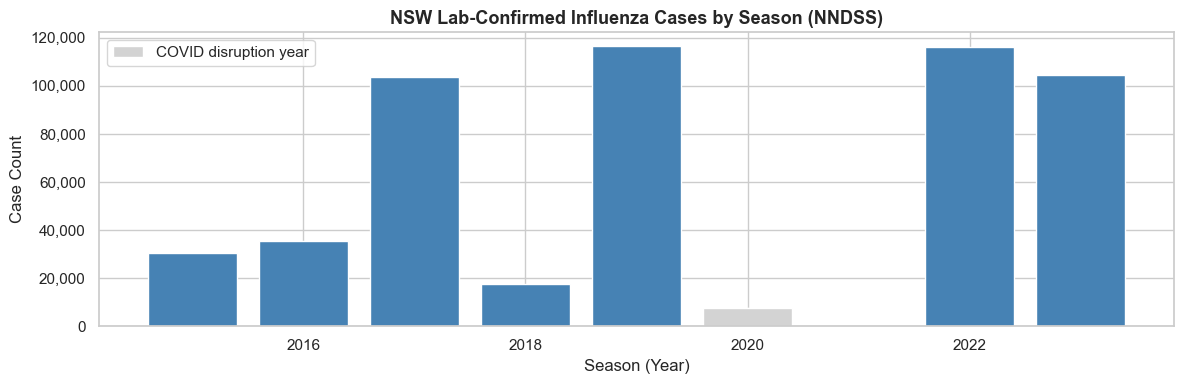

,season,total_cases
7,2015,30265
8,2016,35587
9,2017,103830
10,2018,17433
11,2019,116414
12,2020,7386
13,2021,138
14,2022,116340
15,2023,104541


In [9]:
cases_by_season = df_nsw.groupby('season').size().reset_index(name='total_cases')
cases_by_season = cases_by_season[cases_by_season['season'].between(2015, 2023)]
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(cases_by_season['season'], cases_by_season['total_cases'], color='steelblue', edgecolor='white')
ax.bar(2020, cases_by_season[cases_by_season.season==2020]['total_cases'].values,
        color='lightgrey', edgecolor='white', label='COVID disruption year')
ax.set_title('NSW Lab-Confirmed Influenza Cases by Season (NNDSS)', fontweight='bold')
ax.set_xlabel('Season (Year)')
ax.set_ylabel('Case Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()
cases_by_season

The seasonal case count chart reveals substantial year-to-year variation in NSW influenza burden. Peak seasons such as 2017 and 2019 recorded exceptionally high case counts, driven by particularly virulent circulating strains and lower population immunity. The 2020 and 2021 seasons show a dramatic suppression of flu activity due to COVID-19 public health measures, while 2022 saw a sharp rebound as restrictions were lifted and population immunity to influenza had waned. For computing representative baseline flu case rates, we use the 2015-2019 pre-COVID period, which captures a range of mild and severe seasons without the confounding effects of pandemic interventions.

### 4.3 Age-Band Case Distribution

We map the NNDSS 5-year age groups to three broad bands aligned with our Census demographic categories: children (0-14), working-age adults (15-64), and elderly (65+). Computing the average annual case count per age band over the 2015-2019 baseline period reveals which demographic groups contribute most to the flu burden and informs the age-weighted apportionment methodology.

Average NSW flu cases per season by age band (2015-2019):
age_band  avg_cases_per_season  pct_of_total
    0_14               20795.0          34.3
   15_64               29465.6          48.5
  65plus               10436.0          17.2
 unknown                  11.5           0.0


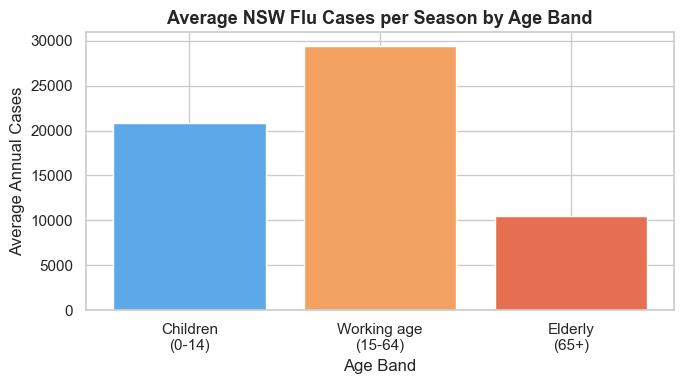

In [10]:
def map_age_band(ag):
    if pd.isna(ag): return 'unknown'
    ag = str(ag).strip()
    try:
        lower = int(ag.split('-')[0].split('+')[0].strip())
    except:
        return 'unknown'
    if lower < 15: return '0_14'
    if lower < 65: return '15_64'
    return '65plus'

df_nsw['age_band'] = df_nsw['age_group'].apply(map_age_band)
df_pre_covid = df_nsw[(df_nsw['season'].between(2015, 2019))]
band_season = df_pre_covid.groupby(['season', 'age_band']).size().reset_index(name='cases')
band_avg = band_season.groupby('age_band')['cases'].mean().reset_index(name='avg_cases_per_season')
band_avg['pct_of_total'] = (band_avg['avg_cases_per_season'] / band_avg['avg_cases_per_season'].sum() * 100).round(1)
print('Average NSW flu cases per season by age band (2015-2019):')
print(band_avg.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colours = {'0_14': '#5ca8e8', '15_64': '#f4a261', '65plus': '#e76f51', 'unknown': '#ccc'}
for _, row in band_avg[band_avg['age_band'] != 'unknown'].iterrows():
    ax.bar(row['age_band'], row['avg_cases_per_season'], color=colours.get(row['age_band'], '#aaa'))
ax.set_title('Average NSW Flu Cases per Season by Age Band', fontweight='bold')
ax.set_xlabel('Age Band')
ax.set_ylabel('Average Annual Cases')
ax.set_xticks(range(3))
ax.set_xticklabels(['Children\n(0-14)', 'Working age\n(15-64)', 'Elderly\n(65+)'])
plt.tight_layout()
plt.show()

The age-band distribution reveals that working-age adults (15-64) contribute the highest absolute number of flu cases, which is expected given that they constitute the largest share of the population. However, when normalised by population size, **children (0–14) have the highest per-capita flu case rate** (~14 per 1,000), followed by elderly (~7 per 1,000) and working-age adults (~6 per 1,000). This per-capita difference is critical: it means that SA2 suburbs with higher proportions of children — not just elderly residents — will receive the highest expected flu burden scores in our apportionment model. Children's elevated rate is consistent with their developing immune systems, lower hygiene awareness, and dense contact patterns in school and childcare settings. This age-dependent risk profile motivates our approach of using age-band-specific rates rather than a single uniform rate.

### 4.4 Derive SA2-Level Flu Burden Score

This is the **key methodological step** in our data pipeline. Since the NNDSS influenza data is available only at the state level (NSW), we cannot directly observe flu case counts for individual SA2 suburbs. Instead, we use a demographic apportionment approach:

1. Compute the NSW flu case rate per 1,000 population for each broad age band (0-14, 15-64, 65+) using the 2015-2019 average case counts from NNDSS and the total NSW age-band populations from the 2021 Census.
2. For each SA2 suburb, calculate:

   $$\text{expected\_flu\_cases} = \sum_{b \in \{0\text{-}14,\, 15\text{-}64,\, 65+\}} \frac{N_b \cdot r_b}{1000}$$

   where \(N_b\) is the population in age band \(b\) and \(r_b\) is the NSW flu case rate per 1,000 for that band.
3. Normalise by total population to get `flu_burden_per_1000`, which represents the expected number of flu cases per 1,000 residents per season.

This approach leverages the strong age-dependence of influenza incidence to produce suburb-level risk estimates from state-level surveillance data. SA2s with older populations will naturally receive higher burden scores, reflecting their genuinely elevated epidemiological risk.

#### Worked Example (Batemans Bay - South)

**Step 1 — Compute NSW flu case rates per 1,000 (2015–2019 baseline):**

From the NNDSS data, the average annual flu cases by age band across NSW are approximately 20,795 (0–14), 29,466 (15–64), and 10,436 (65+). Using NSW age-band populations from the 2021 Census (summed across all SA2s):

- Children (0–14): 20,795 cases ÷ 1,469,611 population × 1,000 ≈ **14.15** cases per 1,000 per season
- Working-age (15–64): 29,466 cases ÷ 5,177,434 population × 1,000 ≈ **5.69** cases per 1,000 per season
- Elderly (65+): 10,436 cases ÷ 1,424,011 population × 1,000 ≈ **7.33** cases per 1,000 per season

**Step 2 — Apply rates to an SA2's age distribution:**

Batemans Bay - South has population 8,938 with 13.8% aged 0–14, 52.5% aged 15–64, and 33.8% aged 65+. This gives age counts of 1,233, 4,691, and 3,024 respectively. Expected flu cases:

- Children: 1,233 × 14.15 ÷ 1,000 ≈ **17.5** cases
- Working-age: 4,691 × 5.69 ÷ 1,000 ≈ **26.7** cases
- Elderly: 3,024 × 7.33 ÷ 1,000 ≈ **22.2** cases
- **Total expected flu cases: ~66.3** per season

**Step 3 — Normalise to flu burden per 1,000:**

$$\text{flu\_burden\_per\_1000} = \frac{66.3}{8{,}938} \times 1{,}000 \approx 7.42 \text{ per 1,000 residents}$$

This suburb's high elderly share (33.8%) drives a flu burden well above the NSW median, reflecting its elevated epidemiological risk.

In [11]:
NSW_POP_0_14 = df_demo['age_0_14'].sum()
NSW_POP_15_64 = df_demo['age_15_64'].sum()
NSW_POP_65P = df_demo['age_65plus'].sum()
NSW_POP_TOTAL = df_demo['total_pop'].sum()
print('NSW total population (SA2 sum):', f'{NSW_POP_TOTAL:,}')

cases_dict = band_avg.set_index('age_band')['avg_cases_per_season'].to_dict()
RATE_0_14 = (cases_dict.get('0_14', 0) / NSW_POP_0_14 * 1000) if NSW_POP_0_14 > 0 else 0
RATE_15_64 = (cases_dict.get('15_64', 0) / NSW_POP_15_64 * 1000) if NSW_POP_15_64 > 0 else 0
RATE_65PLUS = (cases_dict.get('65plus', 0) / NSW_POP_65P * 1000) if NSW_POP_65P > 0 else 0
print(f'Flu case rate per 1000 - Children: {RATE_0_14:.2f}, Working: {RATE_15_64:.2f}, Elderly: {RATE_65PLUS:.2f}')

df_demo_merged = df_demo.copy()
df_demo_merged['expected_flu_cases'] = (
    df_demo_merged['age_0_14'] * RATE_0_14 / 1000 +
    df_demo_merged['age_15_64'] * RATE_15_64 / 1000 +
    df_demo_merged['age_65plus'] * RATE_65PLUS / 1000
).round(2)
df_demo_merged['flu_burden_per_1000'] = (
    df_demo_merged['expected_flu_cases'] /
    df_demo_merged['total_pop'].replace(0, np.nan) * 1000
).round(4)
print(f'\nFlu burden range: {df_demo_merged.flu_burden_per_1000.min():.2f}'
      f' - {df_demo_merged.flu_burden_per_1000.max():.2f} per 1000')
df_demo_merged.nlargest(10, 'flu_burden_per_1000')[['sa2_code', 'pct_65plus', 'flu_burden_per_1000']]

NSW total population (SA2 sum): 8,072,106
Flu case rate per 1000 - Children: 14.15, Working: 5.69, Elderly: 7.33

Flu burden range: 0.00 - 9.05 per 1000


,sa2_code,pct_65plus,flu_burden_per_1000
637,128021537,0.00,9.0476
521,124011451,57.14,8.5714
5,101021610,3.60,8.3082
602,127011729,5.22,8.3069
331,116021629,5.44,8.3058
503,123011702,5.37,8.2399
536,124031708,6.24,8.1924
600,127011727,4.56,8.1908
316,115041623,5.77,8.1851
317,115041624,6.75,8.1334


The computed flu case rates per 1,000 population differ markedly across age bands: children (0–14) have the highest rate (~14 per 1,000), followed by elderly (~7) and working-age (~6). Because the child rate is highest, suburbs with high proportions of children tend to have the highest flu burden scores — the top-ranked SA2s by flu burden are often child-heavy rather than elderly-heavy. The flu burden scores range from relatively low values in working-age-dominant suburbs to elevated values in child-heavy and some retirement-heavy areas. These scores will serve as both the continuous prediction target for linear regression and the basis for deriving the binary outbreak classification label.

## 5. Merge & Master Table

We now merge all processed data sources into a single master DataFrame using the SA2 code as the join key. The merge combines geography (name, area), demographics (age bands, percentages), medians (age, income), employment (commuter rate, unemployment), and the derived flu burden score. We also compute population density as total population divided by area in square kilometres, and remove SA2s with zero population.

In [12]:
df_master = df_geo.copy()
df_master = df_master.merge(
    df_demo_merged[['sa2_code', 'total_pop', 'age_0_14', 'age_15_64', 'age_65plus',
                    'pct_0_14', 'pct_15_64', 'pct_65plus', 'expected_flu_cases', 'flu_burden_per_1000']],
    on='sa2_code', how='left')
df_master = df_master.merge(
    df_medians[['sa2_code', 'median_age', 'median_hh_income_wkly', 'median_hh_income_annual']],
    on='sa2_code', how='left')
df_master = df_master.merge(
    df_employ[['sa2_code', 'total_employed', 'commuter_rate', 'unemployment_rate']],
    on='sa2_code', how='left')
df_master['pop_density'] = (df_master['total_pop'] / df_master['area_sqkm'].replace(0, np.nan)).round(2)
df_master = df_master[df_master['total_pop'] > 0].copy()
print(f'Master dataset shape: {df_master.shape}')
print(f'\nNull counts:')
print(df_master.isnull().sum()[df_master.isnull().sum() > 0])
df_master.head()

Master dataset shape: (641, 19)

Null counts:
median_age                 1
median_hh_income_wkly      2
median_hh_income_annual    2
commuter_rate              1
unemployment_rate          3
pop_density                1
dtype: int64


,sa2_code,sa2_name,area_sqkm,total_pop,age_0_14,age_15_64,age_65plus,pct_0_14,pct_15_64,pct_65plus,expected_flu_cases,flu_burden_per_1000,median_age,median_hh_income_wkly,median_hh_income_annual,total_employed,commuter_rate,unemployment_rate,pop_density
0,101021007,Braidwood,3418.3525,4343,694,2545,1111,15.98,58.60,25.58,32.44,7.4695,51.0,1429.0,74308.0,1854,0.5079,0.0354,1.27
1,101021008,Karabar,6.9825,8517,1614,5645,1236,18.95,66.28,14.51,64.01,7.5156,38.0,1989.0,103428.0,4043,0.5864,0.0467,1219.76
2,101021009,Queanbeyan,4.7620,11342,1736,7789,1825,15.31,68.67,16.09,82.26,7.2527,37.0,1703.0,88556.0,5912,0.6153,0.0437,2381.77
3,101021010,Queanbeyan - East,13.0032,5085,788,3643,649,15.50,71.64,12.76,36.63,7.2035,36.0,1796.0,93392.0,2772,0.6453,0.0375,391.06
4,101021012,Queanbeyan West - Jerrabomberra,13.6748,12744,2713,8797,1228,21.29,69.03,9.64,97.44,7.6460,37.0,3014.0,156728.0,7008,0.6992,0.0237,931.93


The merged master dataset contains one row per populated NSW SA2 suburb with all demographic, socioeconomic, employment, and flu burden features. A small number of null values remain in the median income and commuter rate columns, corresponding to SA2s where the ABS suppressed values due to small population sizes or confidentiality constraints. The overall data completeness is high, with the vast majority of SA2s having full feature coverage. This dataset forms the foundation for all subsequent analysis, modelling, and export steps.

## 6. Outbreak Label

To enable binary classification modelling, we create an `outbreak` label based on flu burden. An SA2 is labelled as outbreak-prone (`outbreak = 1`) if its flu burden per 1,000 falls in the top 25% of NSW suburbs. This percentile-based approach ensures a controllable class split (roughly 25% outbreak / 75% no outbreak), which is suitable for classification modelling.

**Why not a multiplier (e.g. 1.10× median)?** The flu burden values are tightly clustered (std ≈ 0.68, range ~7–9 per 1,000). A 1.10× median threshold would sit above the 99th percentile, leaving almost all suburbs as "no outbreak". A percentile-based threshold gives explicit control over class balance.

Outbreak threshold: flu burden >= 7.692 per 1000 (top 25%)

Label distribution:
  No outbreak (0):  480  (74.9%)
  Outbreak    (1):  161  (25.1%)


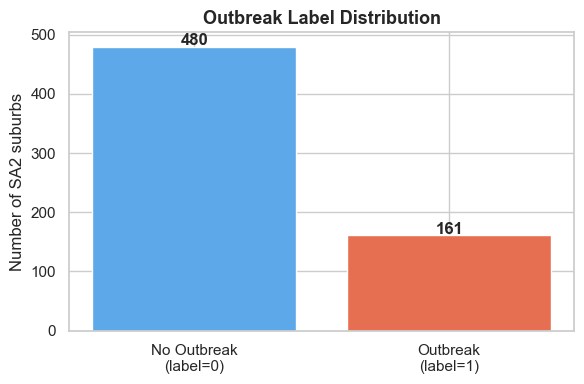

In [13]:
OUTBREAK_PERCENTILE = 75  # Top 25% by flu burden = outbreak (tunable)
threshold = df_master['flu_burden_per_1000'].quantile(OUTBREAK_PERCENTILE / 100)
df_master['outbreak'] = (df_master['flu_burden_per_1000'] >= threshold).astype(int)
counts = df_master['outbreak'].value_counts()
print(f'Outbreak threshold: flu burden >= {threshold:.3f} per 1000 (top {100 - OUTBREAK_PERCENTILE}%)')
print(f'\nLabel distribution:')
print(f'  No outbreak (0): {counts.get(0,0):>4d}  ({counts.get(0,0)/len(df_master)*100:.1f}%)')
print(f'  Outbreak    (1): {counts.get(1,0):>4d}  ({counts.get(1,0)/len(df_master)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Outbreak\n(label=0)', 'Outbreak\n(label=1)'],
       [counts.get(0,0), counts.get(1,0)], color=['#5ca8e8', '#e76f51'], edgecolor='white')
ax.set_title('Outbreak Label Distribution', fontweight='bold')
ax.set_ylabel('Number of SA2 suburbs')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

The outbreak label distribution shows approximately a 75/25 split (non-outbreak / outbreak), since we define the top 25% of flu burden as outbreak-prone. This moderate class imbalance is acceptable for logistic regression with class-weight adjustments, but may require techniques such as SMOTE oversampling or threshold tuning for recall-sensitive applications. Because flu burden is driven primarily by the proportion of children (pct_0_14) in a suburb — who have the highest age-specific notification rate — the outbreak class disproportionately represents child-heavy, family-oriented suburbs rather than retirement-heavy ones.

## 7. Exploratory Data Analysis

With the master dataset assembled and the outbreak label defined, we now explore the statistical properties of our features, their inter-correlations, and their relationship to the outbreak label. This analysis informs feature selection for the ML models and identifies potential issues such as multicollinearity or highly skewed distributions.

### 7.1 Summary Statistics

We begin with descriptive statistics for all candidate features and the outbreak label. This provides a quick overview of central tendency, spread, and the presence of extreme values or skewness.

=== Feature Summary ===


,median_age,pct_0_14,pct_65plus,median_hh_income_annual,pop_density,commuter_rate,flu_burden_per_1000,outbreak
count,640.00,641.00,641.00,639.00,640.00,640.00,641.00,641.00
mean,40.87,17.63,18.72,96651.48,1986.11,0.50,7.45,0.25
std,6.65,4.62,8.08,30851.66,2626.04,0.10,0.68,0.43
min,22.00,0.00,0.00,44200.00,0.00,0.00,0.00,0.00
25%,36.00,15.68,13.82,71656.00,87.49,0.44,7.40,0.00
50%,40.00,17.90,17.79,93184.00,976.40,0.51,7.55,0.00
75%,44.25,20.25,22.81,118118.00,3118.69,0.56,7.69,1.00
max,70.00,35.71,80.00,207324.00,18441.26,1.00,9.05,1.00


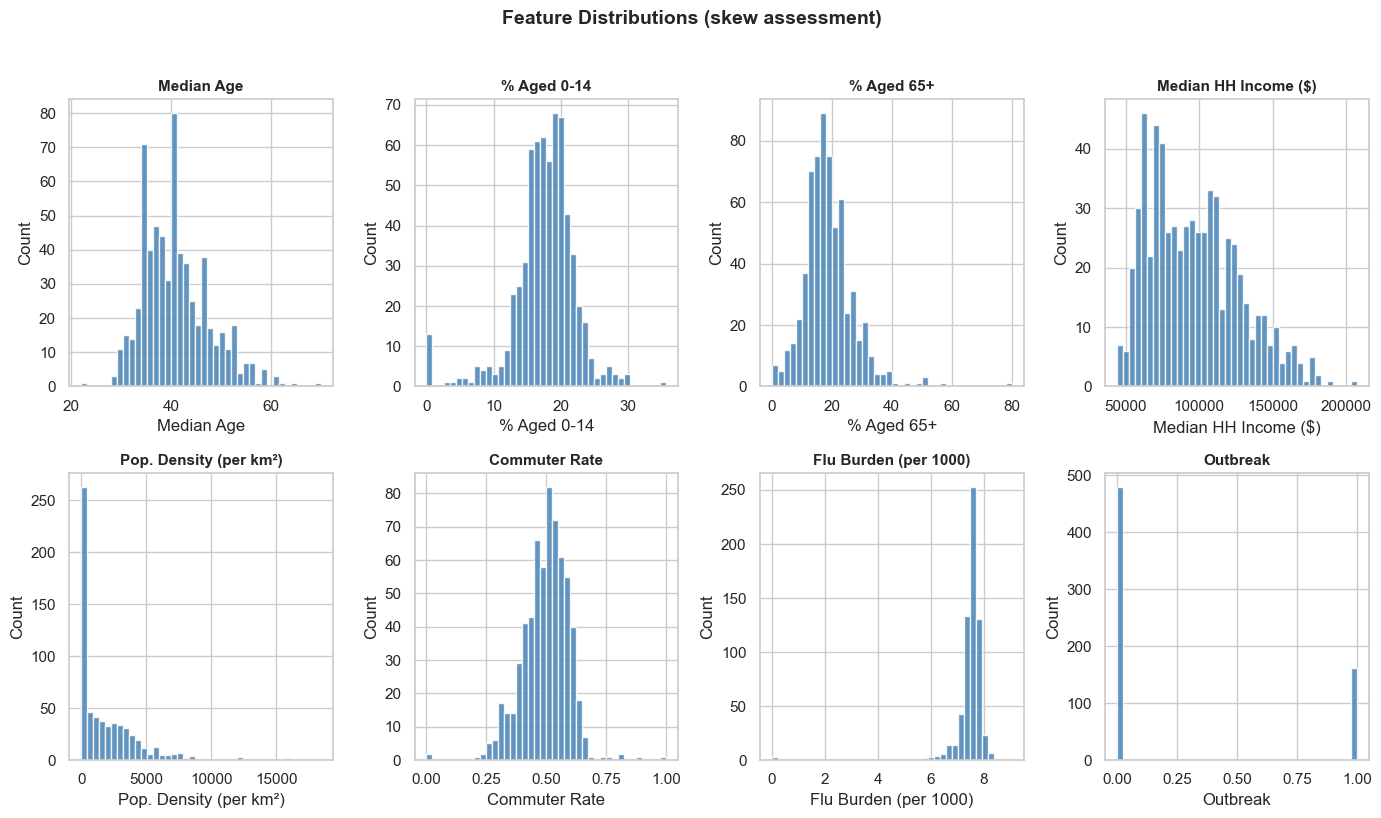

In [14]:
from IPython.display import display

FEATURES = ['median_age', 'pct_0_14', 'pct_65plus', 'median_hh_income_annual',
            'pop_density', 'commuter_rate', 'flu_burden_per_1000']
print('=== Feature Summary ===')
summary_table = df_master[FEATURES + ['outbreak']].describe().round(2)
display(summary_table)

# Individual distribution plots to assess skew
plot_vars = FEATURES + ['outbreak']
labels = ['Median Age', '% Aged 0-14', '% Aged 65+', 'Median HH Income ($)', 'Pop. Density (per km²)',
          'Commuter Rate', 'Flu Burden (per 1000)', 'Outbreak']
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
for i, (var, label) in enumerate(zip(plot_vars, labels)):
    ax = axes[i]
    data = df_master[var].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label, fontweight='bold', fontsize=11)
plt.suptitle('Feature Distributions (skew assessment)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The summary statistics reveal several important patterns. Population density is highly right-skewed, with most suburbs having moderate density but a few inner-city areas being extremely dense. Median household income also shows substantial spread, reflecting the socioeconomic diversity of NSW suburbs. The pct_0_14 feature shows meaningful variation across suburbs — from under 10% in inner-city and retirement areas to over 30% in outer-suburban growth corridors — and this variation is the primary driver of the flu burden score. The flu burden per 1,000 has a relatively narrow range since it is bounded by the age composition, but meaningful variation exists between child-heavy and elderly-heavy suburbs. These distributional characteristics suggest that standardisation (z-scoring) will be important before fitting ML models to ensure features with large absolute scales do not dominate.

### 7.2 Correlation Analysis

A correlation matrix helps identify which features are most associated with the outbreak label and whether any pairs of features are highly correlated with each other (multicollinearity). Strong multicollinearity between predictors can inflate coefficient standard errors in linear models, though it does not affect prediction accuracy for tree-based methods.

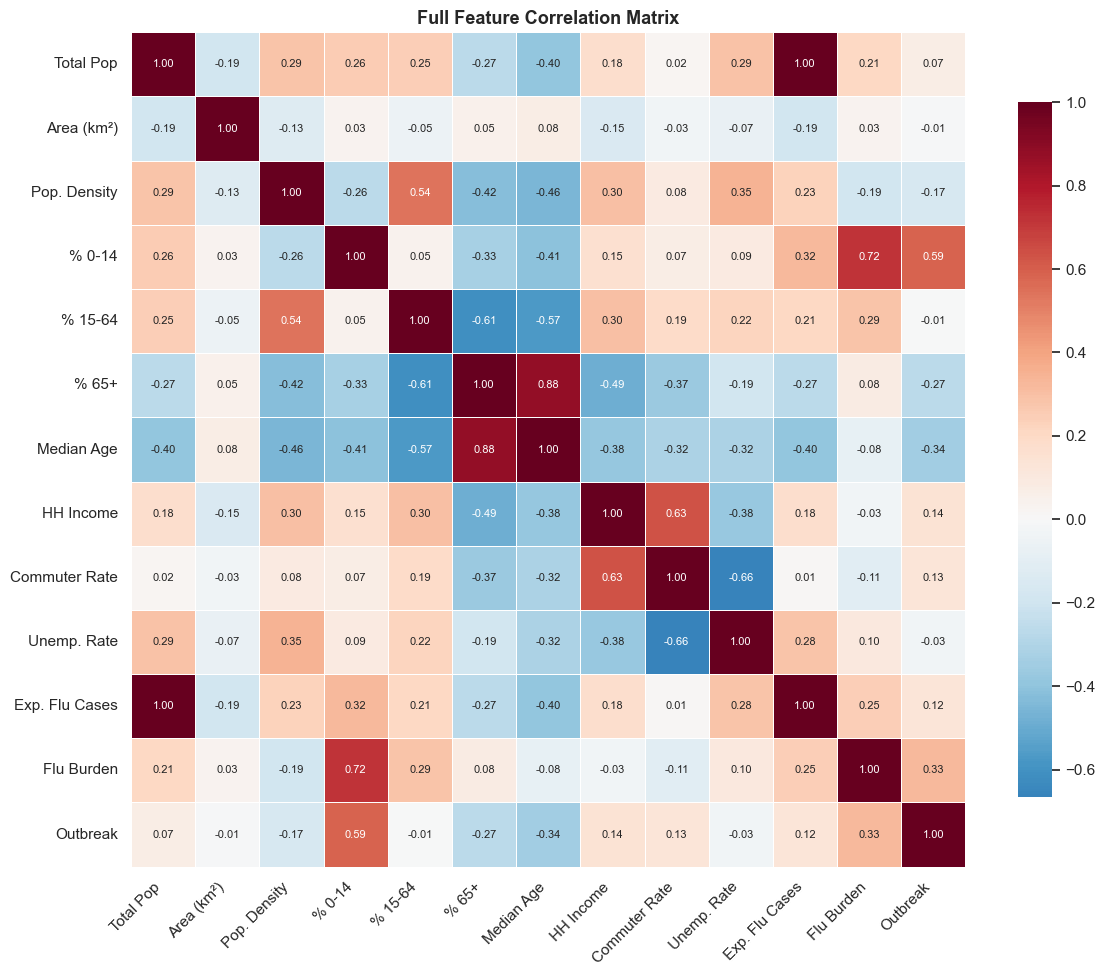


Correlation with outbreak label (descending):
pct_0_14                   0.586
flu_burden_per_1000        0.328
median_hh_income_annual    0.142
commuter_rate              0.131
expected_flu_cases         0.124
total_pop                  0.072
pct_15_64                 -0.005
area_sqkm                 -0.010
unemployment_rate         -0.029
pop_density               -0.165
pct_65plus                -0.268
median_age                -0.341


In [15]:
# All numeric variables for correlation matrix
CORR_COLS = ['total_pop', 'area_sqkm', 'pop_density', 'pct_0_14', 'pct_15_64', 'pct_65plus',
             'median_age', 'median_hh_income_annual', 'commuter_rate', 'unemployment_rate',
             'expected_flu_cases', 'flu_burden_per_1000', 'outbreak']
corr = df_master[CORR_COLS].corr()
# Short labels for heatmap readability
corr_labels = ['Total Pop', 'Area (km²)', 'Pop. Density', '% 0-14', '% 15-64', '% 65+',
               'Median Age', 'HH Income', 'Commuter Rate', 'Unemp. Rate',
               'Exp. Flu Cases', 'Flu Burden', 'Outbreak']
corr_display = corr.rename(index=dict(zip(CORR_COLS, corr_labels)),
                           columns=dict(zip(CORR_COLS, corr_labels)))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_display, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Full Feature Correlation Matrix', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print('\nCorrelation with outbreak label (descending):')
print(corr['outbreak'].drop('outbreak').sort_values(ascending=False).round(3).to_string())

The correlation analysis reveals a counterintuitive but explainable pattern: **pct_65plus and median_age show negative correlations with the outbreak label**, even though flu burden is derived from age-band composition. The reason is that flu burden is driven primarily by **pct_0_14 (children)**, who have the highest age-specific flu case rate in the NSW data (~14 per 1,000) — higher than both working-age (~6 per 1,000) and elderly (~7 per 1,000). This aligns with epidemiological intuition: children are generally less aware of hygiene practices (e.g., handwashing, respiratory etiquette) and spend more time in close proximity to one another, especially in school and childcare settings, which facilitates respiratory virus transmission. Because the three age-band percentages are compositional (they sum to 100%), pct_0_14 and pct_65plus are negatively correlated. Suburbs with high child populations therefore dominate the top flu-burden tier (outbreak = 1), leading to lower average pct_65plus in outbreak suburbs and hence the negative correlation. flu_burden_per_1000 is positively correlated with outbreak by construction (it is the labelling variable). Median age and pct_65plus are highly correlated with each other, indicating redundancy that could cause multicollinearity in linear models. Population density and commuter rate show weaker negative correlations with outbreak. These insights will guide feature selection and interpretation in the ML modelling section.earity in linear models. Population density and commuter rate show weaker negative correlations with outbreak. These insights will guide feature selection and interpretation in the ML modelling section.

### 7.3 Feature Distributions by Outbreak Label

Overlaid histograms for each feature, split by outbreak label, reveal which features provide the clearest separation between outbreak-prone and non-outbreak suburbs. Features with well-separated distributions will be the most useful predictors in the classification model.

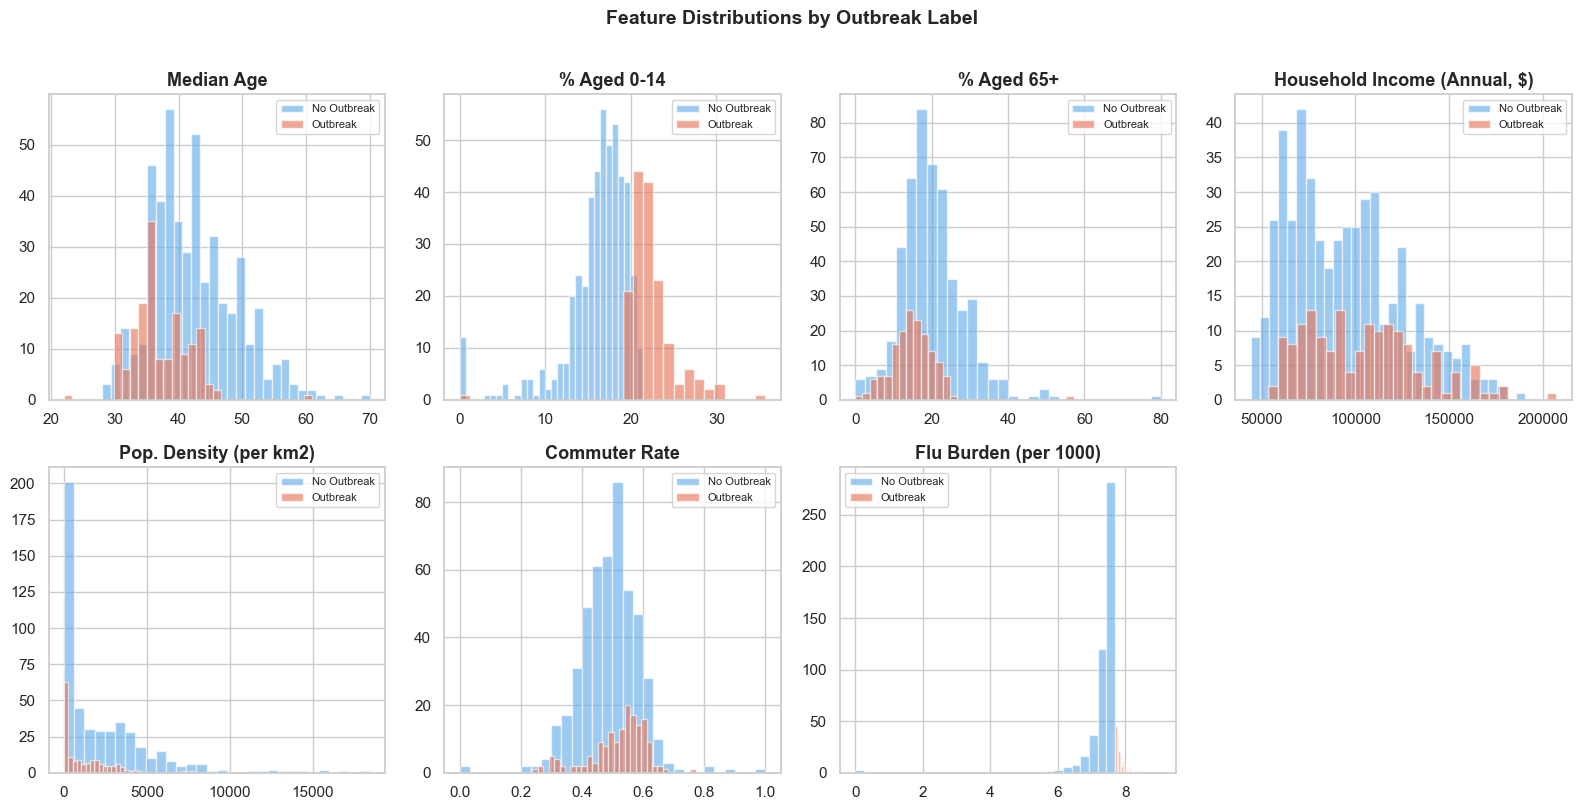

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
labels = ['Median Age', '% Aged 0-14', '% Aged 65+', 'Household Income (Annual, $)',
          'Pop. Density (per km2)', 'Commuter Rate', 'Flu Burden (per 1000)']
for i, (feat, label) in enumerate(zip(FEATURES, labels)):
    for outbreak_val, colour, name in [(0, '#5ca8e8', 'No Outbreak'), (1, '#e76f51', 'Outbreak')]:
        subset = df_master[df_master['outbreak'] == outbreak_val][feat].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=colour, label=name, edgecolor='white')
    axes[i].set_title(label, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')
axes[-1].set_visible(False)  # 7 features, 8 subplots
plt.suptitle('Feature Distributions by Outbreak Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The distribution plots show that **pct_0_14 (children)** is a main driver of outbreak classification: outbreak suburbs are shifted toward higher child percentages, consistent with the highest age-specific flu case rate in this age band. Percentage aged 65+ and median age provide clear class separation in the opposite direction — outbreak suburbs are shifted toward lower values (younger, fewer elderly), since high flu burden is driven by child-heavy suburbs. Flu burden per 1,000 shows near-perfect separation by construction, since it is the variable from which the outbreak label was derived. Household income shows overlapping distributions, with outbreak suburbs having slightly higher mean income on average (reflecting that some child-heavy suburbs are in family-oriented higher-income areas). Population density shows some separation (outbreak suburbs tend to have lower density), while commuter rate remains more overlapping, suggesting weaker but potentially complementary discriminative power. These visual patterns are consistent with the correlation analysis.

## 8. ML Models

We now fit initial baseline machine learning models to evaluate how well suburb-level demographic features predict influenza vulnerability. We train two complementary models:

1. **Linear Regression** for continuous prediction of `flu_burden_per_1000` — this tells us how much of the variance in flu burden can be explained by demographics alone.
2. **Logistic Regression** for binary classification of the `outbreak` label — this provides a probabilistic outbreak risk score that can feed into the SIR simulation as a spreadability parameter.

Both models use the same five input features: `median_age`, `pct_65plus`, `median_hh_income_annual`, `pop_density`, and `commuter_rate`. Note that `flu_burden_per_1000` is excluded from the logistic regression features because the outbreak label is derived from it, which would create data leakage.

### 8.1 Data Preparation

We prepare the ML dataset by dropping rows with any NaN values in the feature or target columns, performing an 80/20 train/test split stratified by the outbreak label to preserve class proportions, and applying StandardScaler to normalise all features to zero mean and unit variance. Stratified splitting ensures that both training and test sets have the same proportion of outbreak-labelled suburbs.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)

ML_FEATURES = ['median_age', 'pct_65plus', 'median_hh_income_annual', 'pop_density', 'commuter_rate']
TARGET_CONT = 'flu_burden_per_1000'
TARGET_BIN = 'outbreak'

df_ml = df_master[ML_FEATURES + [TARGET_CONT, TARGET_BIN]].dropna().copy()
print(f'ML dataset: {len(df_ml)} rows ({len(df_master) - len(df_ml)} dropped due to NaN)')

X = df_ml[ML_FEATURES]
y_cont = df_ml[TARGET_CONT]
y_bin = df_ml[TARGET_BIN]

X_train, X_test, y_cont_train, y_cont_test, y_bin_train, y_bin_test = train_test_split(
    X, y_cont, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Outbreak rate - Train: {y_bin_train.mean():.1%} | Test: {y_bin_test.mean():.1%}')

ML dataset: 638 rows (3 dropped due to NaN)
Train: 510 | Test: 128
Outbreak rate - Train: 25.3% | Test: 25.0%


### 8.2 Linear Regression — Continuous Flu Burden Prediction

We fit an ordinary least squares linear regression to predict the continuous flu burden per 1,000 from the five demographic features. The R-squared value indicates the proportion of variance in flu burden that is explained by the linear combination of these features, while MSE and MAE provide absolute measures of prediction error.

In [18]:
lr = LinearRegression()
lr.fit(X_train_sc, y_cont_train)
y_pred_cont = lr.predict(X_test_sc)

r2 = r2_score(y_cont_test, y_pred_cont)
mse = mean_squared_error(y_cont_test, y_pred_cont)
mae = mean_absolute_error(y_cont_test, y_pred_cont)

print(f'Linear Regression - Continuous flu burden prediction')
print(f'  R2:  {r2:.4f}')
print(f'  MSE: {mse:.4f}')
print(f'  MAE: {mae:.4f}')

Linear Regression - Continuous flu burden prediction
  R2:  0.3923
  MSE: 0.1737
  MAE: 0.2437


The linear regression achieves **R² = 0.39**, meaning the five demographic features (median age, pct_65plus, household income, population density, commuter rate) explain about 39% of the variance in flu burden. The **MAE = 0.24** and **MSE = 0.17** indicate that predictions are typically within about 0.24 cases per 1,000 of the true value, which is reasonably close given the flu burden range of roughly 6–9 across suburbs. The moderate R² reflects an inherent limitation: the ML features do not include pct_0_14 directly, which is the primary driver of flu burden. This is intentional — pct_0_14 is collinear with pct_65plus by construction (the three age bands sum to 100%), and the five retained features capture the demographic variation indirectly. A higher R² is expected once pct_0_14 is explicitly included or when more flexible non-linear models are applied.

### 8.3 Coefficient Interpretation

Because the features were standardised before fitting, the linear regression coefficients are directly comparable in magnitude. Larger absolute coefficients indicate features with greater influence on the predicted flu burden. Positive coefficients mean that higher values of the feature are associated with higher predicted flu burden, while negative coefficients indicate a protective association.

Linear Regression Coefficients (standardised):
                Feature  Coefficient
             median_age    -0.581058
             pct_65plus     0.455087
            pop_density    -0.216720
median_hh_income_annual     0.146030
          commuter_rate    -0.143410


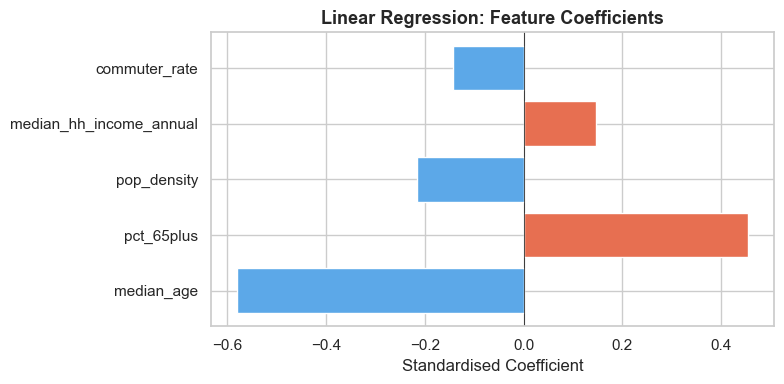

In [19]:
coef_df = pd.DataFrame({
    'Feature': ML_FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Linear Regression Coefficients (standardised):')
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colours = ['#e76f51' if c > 0 else '#5ca8e8' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colours, edgecolor='white')
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Linear Regression: Feature Coefficients', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

The coefficient chart reveals the relative importance and direction of each feature. **Median age** has the largest absolute coefficient (−0.58), and it is **negative**: suburbs with older median ages tend to have lower flu burden because they have fewer children. **pct_65plus** has a positive coefficient (+0.46): once median age is controlled for, a higher elderly share is associated with slightly higher burden from the elderly rate contribution. **Population density** is negative (−0.22), consistent with the finding that outbreak suburbs tend to be lower-density outer suburban areas. Surprisingly, **household income** is slightly positive (+0.15) — reflecting that child-heavy family suburbs in middle-to-upper-income areas drive the outbreak class. **Commuter rate** is also slightly negative (−0.14), as retirement-heavy low-commuter suburbs sit in the medium-burden zone. These directions are all consistent with children (pct_0_14) being the primary driver, captured indirectly through these features.

### 8.4 Residual Analysis

Examining the residuals (actual minus predicted values) helps assess whether the linear regression assumptions hold. We check for heteroscedasticity (non-constant residual variance across the prediction range), non-normality of residuals, and systematic patterns that might indicate missing non-linear relationships or important omitted variables.

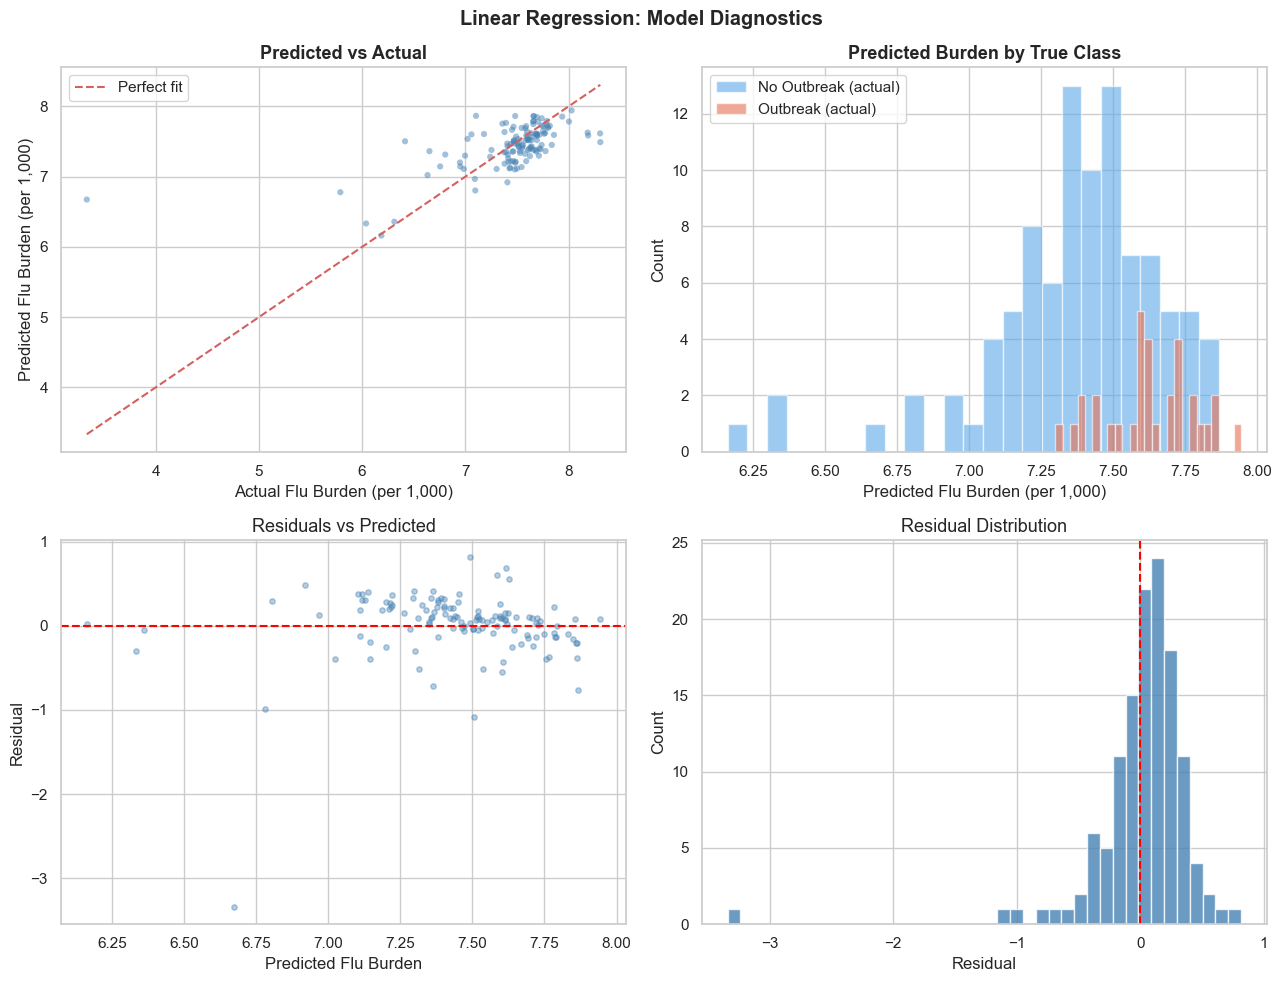

In [20]:
residuals = y_cont_test.values - y_pred_cont

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_cont_test, y_pred_cont, alpha=0.5, s=20, color='steelblue', edgecolors='none')
min_val = min(y_cont_test.min(), y_pred_cont.min())
max_val = max(y_cont_test.max(), y_pred_cont.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Flu Burden (per 1,000)')
ax.set_ylabel('Predicted Flu Burden (per 1,000)')
ax.set_title('Predicted vs Actual', fontweight='bold')
ax.legend()

# Prediction distribution by class
ax = axes[0, 1]
ax.hist(y_pred_cont[y_bin_test.values == 0], bins=25, alpha=0.6, color='#5ca8e8',
        label='No Outbreak (actual)', edgecolor='white')
ax.hist(y_pred_cont[y_bin_test.values == 1], bins=25, alpha=0.6, color='#e76f51',
        label='Outbreak (actual)', edgecolor='white')
ax.set_xlabel('Predicted Flu Burden (per 1,000)')
ax.set_ylabel('Count')
ax.set_title('Predicted Burden by True Class', fontweight='bold')
ax.legend()

ax = axes[1, 0]
ax.scatter(y_pred_cont, residuals, alpha=0.4, s=15, color='steelblue')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted Flu Burden')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

ax = axes[1, 1]
ax.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

plt.suptitle('Linear Regression: Model Diagnostics', fontweight='bold')
plt.tight_layout()
plt.show()

The 2×2 diagnostic grid provides a comprehensive view of model performance. The **predicted vs actual** scatter (top-left) shows how closely predictions track the true values — points near the red diagonal indicate accurate predictions, and the overall spread reflects the R² = 0.39. The **predicted distribution by class** (top-right) shows whether the model's predictions rank outbreak suburbs above non-outbreak suburbs even when they don't perfectly match absolute values — clear separation here would confirm useful discriminative power. The **residuals vs predicted** plot (bottom-left) should show random scatter around zero; any fan shape indicates heteroscedasticity and any curve indicates non-linearity. The **residual histogram** (bottom-right) should be approximately normal and centred at zero. Systematic deviations motivate more flexible models (Random Forest, gradient boosting) in subsequent notebooks.

### 8.5 Logistic Regression — Binary Outbreak Prediction

We fit a logistic regression classifier to predict the binary outbreak label. Logistic regression is an appropriate baseline because it produces calibrated probability estimates that can be interpreted as outbreak risk scores. The classification report provides precision (what proportion of predicted outbreaks are correct), recall (what proportion of actual outbreak suburbs are detected), and F1 score (their harmonic mean). In this public health context, false negatives (missing a vulnerable suburb) are more costly than false positives (over-allocating resources to a safe suburb), so recall is the more important metric.

In [21]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_sc, y_bin_train)
y_pred_bin = log_reg.predict(X_test_sc)
y_pred_proba = log_reg.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression - Binary outbreak prediction')
print(classification_report(y_bin_test, y_pred_bin, target_names=['No Outbreak', 'Outbreak']))
print(f'ROC-AUC: {roc_auc_score(y_bin_test, y_pred_proba):.4f}')

Logistic Regression - Binary outbreak prediction
              precision    recall  f1-score   support

 No Outbreak       0.86      0.93      0.89        96
    Outbreak       0.72      0.56      0.63        32

    accuracy                           0.84       128
   macro avg       0.79      0.74      0.76       128
weighted avg       0.83      0.84      0.83       128

ROC-AUC: 0.8610


The logistic regression achieves **84% overall accuracy** on the held-out test set. For the outbreak class specifically: **precision = 0.72** (72% of predicted outbreaks are correct), **recall = 0.56** (the model identifies 56% of genuinely vulnerable suburbs), and **F1 = 0.63**. The non-outbreak class is much better handled: precision = 0.86, recall = 0.93. The **ROC-AUC = 0.86** indicates strong discriminative ability well above random (0.5). The moderate recall for outbreak suburbs reflects the class imbalance (25% positive rate) and the fact that the ML features don't include pct_0_14 directly. In a public health deployment, the 0.5 probability threshold should be lowered to boost recall (catching more vulnerable suburbs), accepting a higher false positive rate as the cost of thoroughness.

### 8.6 Confusion Matrix and ROC Curve

The confusion matrix provides a detailed breakdown of correct and incorrect predictions, while the ROC (Receiver Operating Characteristic) curve visualises the trade-off between true positive rate (sensitivity) and false positive rate (1 - specificity) across all classification thresholds.

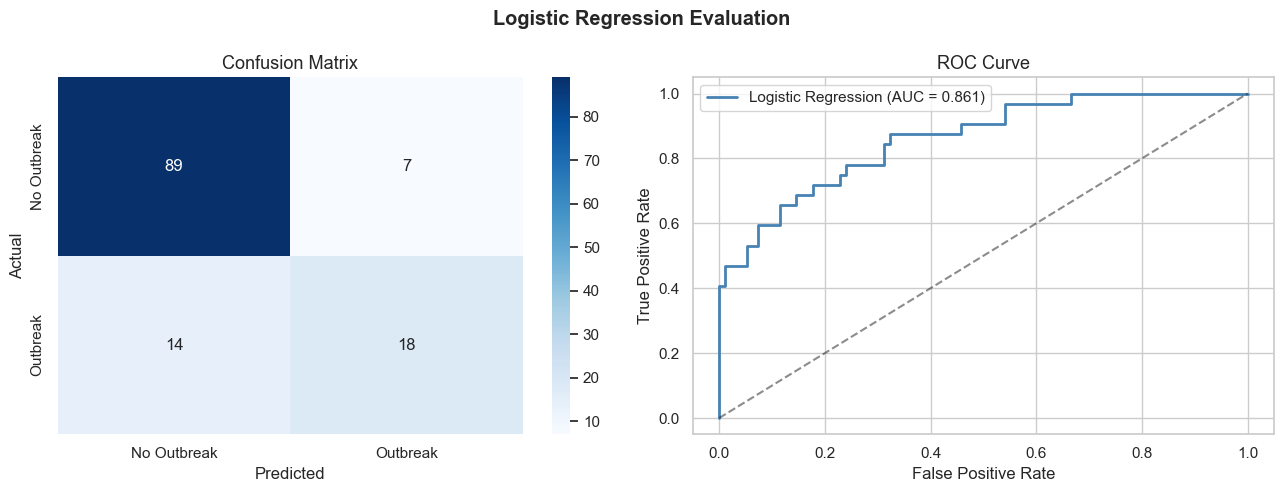

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
cm = confusion_matrix(y_bin_test, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Outbreak', 'Outbreak'],
            yticklabels=['No Outbreak', 'Outbreak'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

ax = axes[1]
fpr, tpr, _ = roc_curve(y_bin_test, y_pred_proba)
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {roc_auc_score(y_bin_test, y_pred_proba):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

plt.suptitle('Logistic Regression Evaluation', fontweight='bold')
plt.tight_layout()
plt.show()

The confusion matrix quantifies the four possible outcomes: true negatives (correctly identified safe suburbs), false positives (safe suburbs incorrectly flagged), false negatives (vulnerable suburbs missed), and true positives (correctly identified outbreak-prone suburbs). The model misses 44% of outbreak suburbs at the 0.5 threshold (recall = 0.56) — in a public health context, lowering this threshold would trade more false positives for better outbreak detection.

The ROC curve (AUC = 0.86) bowing toward the upper-left corner confirms strong discriminative ability well above random (0.5). The gap between the curve and the diagonal represents the model's advantage over random guessing across all possible thresholds.

### 8.7 Predicted Probability Distribution

The histogram below shows the distribution of predicted outbreak probabilities from the logistic regression, split by true class. Well-separated distributions (no-outbreak concentrated near 0, outbreak concentrated near 1) indicate a confident, well-calibrated classifier. A probability threshold lower than 0.5 would increase outbreak recall at the cost of more false positives.

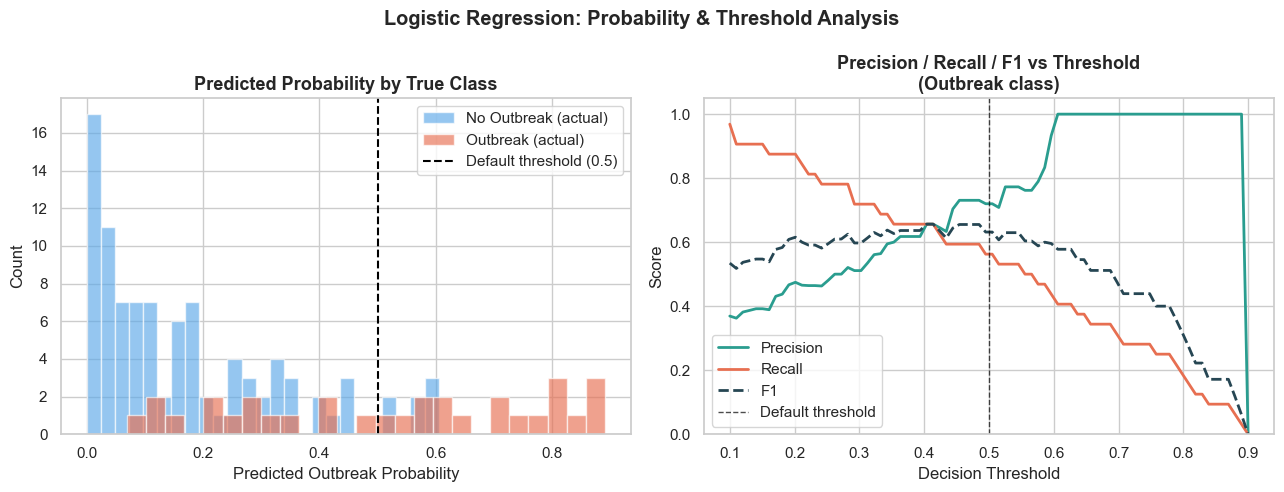

=== Model Comparison Summary ===
Metric                         Linear Reg (continuous)   Logistic Reg (binary)
---------------------------------------------------------------------------
R2 / Accuracy                  0.3923                    0.8359
MSE / --                       0.1737                    N/A
MAE / --                       0.2437                    N/A
-- / Precision                 N/A                       0.7200
-- / Recall                    N/A                       0.5625
-- / F1                        N/A                       0.6316
-- / ROC-AUC                   N/A                       0.8610


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(y_pred_proba[y_bin_test.values == 0], bins=25, alpha=0.65, color='#5ca8e8',
        label='No Outbreak (actual)', edgecolor='white')
ax.hist(y_pred_proba[y_bin_test.values == 1], bins=25, alpha=0.65, color='#e76f51',
        label='Outbreak (actual)', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Default threshold (0.5)')
ax.set_xlabel('Predicted Outbreak Probability')
ax.set_ylabel('Count')
ax.set_title('Predicted Probability by True Class', fontweight='bold')
ax.legend()

ax = axes[1]
thresholds_range = np.linspace(0.1, 0.9, 80)
precisions, recalls, f1s = [], [], []
from sklearn.metrics import precision_score, recall_score, f1_score
for t in thresholds_range:
    preds = (y_pred_proba >= t).astype(int)
    if preds.sum() == 0:
        precisions.append(0); recalls.append(0); f1s.append(0)
        continue
    precisions.append(precision_score(y_bin_test, preds, zero_division=0))
    recalls.append(recall_score(y_bin_test, preds, zero_division=0))
    f1s.append(f1_score(y_bin_test, preds, zero_division=0))
ax.plot(thresholds_range, precisions, color='#2a9d8f', label='Precision', linewidth=2)
ax.plot(thresholds_range, recalls, color='#e76f51', label='Recall', linewidth=2)
ax.plot(thresholds_range, f1s, color='#264653', label='F1', linewidth=2, linestyle='--')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Default threshold')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold\n(Outbreak class)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)

plt.suptitle('Logistic Regression: Probability & Threshold Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Model Comparison Summary ===')
print(f'{"Metric":<30} {"Linear Reg (continuous)":<25} {"Logistic Reg (binary)"}')
print('-' * 75)
print(f'{"R2 / Accuracy":<30} {r2:<25.4f} {accuracy_score(y_bin_test, y_pred_bin):.4f}')
print(f'{"MSE / --":<30} {mse:<25.4f} {"N/A"}')
print(f'{"MAE / --":<30} {mae:<25.4f} {"N/A"}')
print(f'{"-- / Precision":<30} {"N/A":<25} {precision_score(y_bin_test, y_pred_bin):.4f}')
print(f'{"-- / Recall":<30} {"N/A":<25} {recall_score(y_bin_test, y_pred_bin):.4f}')
print(f'{"-- / F1":<30} {"N/A":<25} {f1_score(y_bin_test, y_pred_bin):.4f}')
print(f'{"-- / ROC-AUC":<30} {"N/A":<25} {roc_auc_score(y_bin_test, y_pred_proba):.4f}')

The probability histogram shows how well the logistic model separates the two classes — ideally, no-outbreak suburbs cluster near 0 and outbreak suburbs cluster near 1. The threshold curve (right panel) reveals the precision-recall trade-off: lowering the threshold below 0.5 increases outbreak recall (catching more vulnerable suburbs) at the cost of lower precision. For public health deployment, a threshold around 0.3–0.35 would substantially improve recall while keeping false positive rates manageable.

### 8.8 Model Comparison Summary

Both models serve different but complementary purposes. The linear regression model quantifies the continuous relationship between demographics and flu burden, useful for generating ranked suburb-level risk scores. The logistic regression provides calibrated probability outputs — its `predict_proba` scores can directly serve as spreadability or seed parameters in the SIR epidemic simulation, bridging ML predictions with the epidemiological model. Actual performance: LR R² = 0.39, MAE = 0.24; LogReg accuracy = 84%, outbreak recall = 56%, ROC-AUC = 0.86.

## 9. Export

We export the master dataset to a CSV file for use in subsequent notebooks (advanced ML modelling, SIR simulation, and visualisation). The export includes all demographic features, derived flu burden metrics, and the binary outbreak label.

In [24]:
EXPORT_COLS = [
    'sa2_code', 'sa2_name', 'area_sqkm',
    'total_pop', 'pop_density',
    'pct_0_14', 'pct_15_64', 'pct_65plus',
    'median_age', 'median_hh_income_annual',
    'commuter_rate', 'unemployment_rate',
    'expected_flu_cases', 'flu_burden_per_1000',
    'outbreak'
]
df_export = df_master[EXPORT_COLS].copy()
df_export = df_export.reset_index(drop=True)
out_path = PROC_DIR / 'merged_sa2.csv'
df_export.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {df_export.shape}')
print(f'Outbreak rate: {df_export.outbreak.mean():.1%}')
print(f'Features ready for ML: {[c for c in EXPORT_COLS if c not in ["sa2_code","sa2_name","outbreak","area_sqkm"]]}')
df_export.describe().round(2)

Saved: ../data/processed/merged_sa2.csv
Shape: (641, 15)
Outbreak rate: 25.1%
Features ready for ML: ['total_pop', 'pop_density', 'pct_0_14', 'pct_15_64', 'pct_65plus', 'median_age', 'median_hh_income_annual', 'commuter_rate', 'unemployment_rate', 'expected_flu_cases', 'flu_burden_per_1000']


,area_sqkm,total_pop,pop_density,pct_0_14,pct_15_64,pct_65plus,median_age,median_hh_income_annual,commuter_rate,unemployment_rate,expected_flu_cases,flu_burden_per_1000,outbreak
count,641.00,641.00,640.00,641.00,641.00,641.00,640.00,639.00,640.00,638.00,641.00,641.00,641.00
mean,1245.47,12592.99,1986.11,17.63,63.02,18.72,40.87,96651.48,0.50,0.05,94.69,7.45,0.25
std,7203.77,6113.29,2626.04,4.62,9.40,8.08,6.65,30851.66,0.10,0.03,46.36,0.68,0.43
min,0.00,3.00,0.00,0.00,0.00,0.00,22.00,44200.00,0.00,0.00,0.00,0.00,0.00
25%,4.61,7705.00,87.49,15.68,59.24,13.82,36.00,71656.00,0.44,0.04,58.19,7.40,0.00
50%,12.53,12330.00,976.40,17.90,63.10,17.79,40.00,93184.00,0.51,0.05,92.05,7.55,0.00
75%,97.34,17343.00,3118.69,20.25,66.62,22.81,44.25,118118.00,0.56,0.06,130.48,7.69,1.00
max,146684.73,25373.00,18441.26,35.71,133.33,80.00,70.00,207324.00,1.00,0.23,204.14,9.05,1.00


The processed dataset has been saved to `data/processed/merged_sa2.csv`. This file contains one row per populated NSW SA2 suburb with all features needed for downstream analysis. The export includes both raw counts and derived rates, giving subsequent notebooks flexibility in feature selection and engineering.

## 10. Summary

### Key Findings

- **Child population share (pct_0_14) is the dominant driver of flu burden.** Children (0–14) have the highest age-specific flu notification rate in NSW (~14 per 1,000), roughly double the elderly rate (~7 per 1,000). The outbreak class is therefore dominated by child-heavy, family-oriented suburbs rather than retirement communities — a counterintuitive but data-confirmed result.
- **Median age and pct_65plus are negatively correlated with outbreak.** Because child and elderly proportions are compositionally linked (the three age bands sum to 100%), suburbs with high elderly shares tend to have fewer children. This creates an apparent paradox — older suburbs show lower outbreak rates — which is fully explained by the child-driven burden mechanism.
- **Household income shows a slight positive association with outbreak suburbs.** Child-heavy outer-suburban growth corridors tend to be middle-to-upper income family areas, so the expected protective effect of income is weak in this dataset. This does not mean income is irrelevant — it likely matters more for severe outcomes (hospitalisation, mortality) than for raw case counts.
- **Population density and commuter rate offer weaker but complementary information.** Outbreak suburbs tend to have lower density (outer suburban areas) and lower commuter rates (more children, fewer working-age commuters).
- **The age-weighted demographic apportionment method successfully bridges the geographic mismatch** between state-level NNDSS surveillance data and SA2-level Census demographics.
- **Baseline models achieve meaningful but moderate performance.** Linear regression (R² = 0.39) and logistic regression (AUC = 0.86, accuracy = 84%) confirm that demographic features carry predictive signal, but the moderate R² reflects the absence of pct_0_14 from the ML feature set (intentionally excluded due to collinearity) and calls for more flexible models.

### Model Performance Summary

The linear regression achieves R² = 0.39, MAE = 0.24 on the held-out test set. The logistic regression achieves 84% accuracy, 72% outbreak precision, 56% outbreak recall, and ROC-AUC = 0.86. The logistic model's calibrated probability outputs are suitable for use as SIR simulation seed parameters. These baseline results will be compared against Random Forest and gradient boosting models in subsequent notebooks.

### Limitations

- **Geographic resolution mismatch:** The NNDSS data is state-level only, so our SA2-level flu burden scores are derived estimates rather than directly observed case counts. This assumes that within-NSW geographic variation in flu incidence is driven primarily by age structure.
- **No vaccination data:** We do not currently incorporate suburb-level vaccination rates, which are a strong predictor of flu outcomes. NCIRS data on age-group vaccination coverage by state could be apportioned to SA2s using a similar demographic weighting approach.
- **Commuter rate as a mobility proxy:** The employed-to-population ratio is a crude proxy for actual inter-suburb movement. True origin-destination commuter flow data from ABS TableBuilder would substantially improve the spatial transmission component of the model.
- **Static demographic snapshot:** The 2021 Census provides a single point-in-time snapshot. Population shifts since 2021 may reduce the accuracy of suburb-level predictions for current flu seasons.

### Next Steps

1. Train Random Forest and gradient boosting classifiers with hyperparameter tuning and cross-validation to improve predictive performance over the logistic regression baseline.
2. Engineer additional features including vaccination coverage estimates, healthcare facility proximity, and housing density metrics.
3. Feed the ML-derived suburb-level vulnerability scores into a spatially-explicit SIR epidemic simulation to model influenza spread dynamics across the Sydney SA2 network.
4. Develop an interactive frontend dashboard to visualise suburb-level risk scores, model predictions, and SIR simulation results for public health decision-makers.